# momentum concept
rigorous analysis:
- On the Momentum Term in Gradient Descent Learning Algorithms (https://www.sciencedirect.com/science/article/pii/S0893608098001166)

just newtonian physics, SODE. read above for stability analysis



$\begin{aligned}
v_t &= \gamma v_{t-1} + \eta \nabla_\theta J(\theta) \\
\theta &= \theta - v_t
\end{aligned}$

gradient descent + a little momentum from term (gradient of last step mostly)

In [1]:
import torch
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [15]:
alpha = 0.001 # lr
gamma = 0.9

theta = torch.tensor([1.0], requires_grad=True) # starting value
v_t = 0 # init
t = 0

plt_theta = [theta.item()]
while True:
	t += 1

	fn = (theta**2).sum()
	fn.backward() # backprop to find grad
	g = theta.grad # gradient of function @ theta

	# MAIN LOGIC
	v_t = gamma * v_t + alpha * g
	with torch.no_grad():
		theta -= v_t
	
	if jnp.isnan(theta.item()):
		print(f"NaN at step {t}, theta = {theta.item()}")
		print(f"Gradient: {g.item()}")
		break

	# print(theta.item())
	plt_theta.append(theta.item())

	# converged (gradient is zero)
	if abs(g).max() < 1e-3:
		print(f"Converged at step {t}, theta = {theta.item()}")
		print(f"Final gradient: {g.item()}")
		break

	theta.grad.zero_()

Converged at step 300, theta = 0.0004772502579726279
Final gradient: 0.0009804678848013282


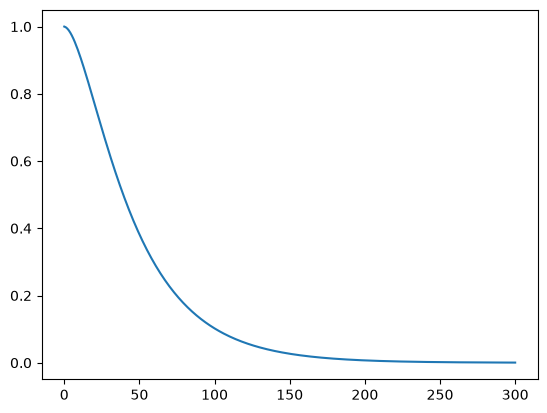

In [16]:
plt.plot(plt_theta)

```bibtex
@article{QIAN1999145,
	title = {On the momentum term in gradient descent learning algorithms},
	journal = {Neural Networks},
	volume = {12},
	number = {1},
	pages = {145-151},
	year = {1999},
	issn = {0893-6080},
	doi = {https://doi.org/10.1016/S0893-6080(98)00116-6},
	url = {https://www.sciencedirect.com/science/article/pii/S0893608098001166},
	author = {Ning Qian},
	keywords = {Momentum, Gradient descent learning algorithm, Damped harmonic oscillator, Critical damping, Learning rate, Speed of convergence},
	abstract = {A momentum term is usually included in the simulations of connectionist learning algorithms. Although it is well known that such a term greatly improves the speed of learning, there have been few rigorous studies of its mechanisms. In this paper, I show that in the limit of continuous time, the momentum parameter is analogous to the mass of Newtonian particles that move through a viscous medium in a conservative force field. The behavior of the system near a local minimum is equivalent to a set of coupled and damped harmonic oscillators. The momentum term improves the speed of convergence by bringing some eigen components of the system closer to critical damping. Similar results can be obtained for the discrete time case used in computer simulations. In particular, I derive the bounds for convergence on learning-rate and momentum parameters, and demonstrate that the momentum term can increase the range of learning rate over which the system converges. The optimal condition for convergence is also analyzed.}
	}
```